In [2]:
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
#optimization problem we're gonna experiment on: Bob's Bakery Problem
#ground truth mathematical model: 
'''
objective: 10*x1 + 12*x2
constraints: 
        5*x1 + 4*x2 <= 50
        2*x1 + 4*x2 <= 30
          x1 + 2*x2 <= 20
          x1 >= 0
          x2 >= 0
'''
#we are gonna try four variants of the mathematical model that a LLM might produce:
#variant 1: the LLM misses a constraint
'''
objective: 10*x1 + 12*x2
constraints: 
        5*x1 + 4*x2 <= 50
        2*x1 + 4*x2 <= 30
          x1 >= 0
          x2 >= 0
'''
#variant 2: the LLM switches ordering of some terms in the constraints
'''
objective: 10*x1 + 12*x2
constraints: 
        5*x1 <= 50 - 4*x2
        4*x2 <= 30 - 2*x1
          x1 + 2*x2 <= 20
          x1 >= 0
          x2 >= 0
'''
#variant 3: the LLM misses a constraint and switches ordering of some terms in the constraints
'''
objective: 10*x1 + 12*x2
constraints: 
        5*x1 <= 50 - 4*x2
        4*x2 <= 30 - 2*x1
          x1 >= 0
          x2 >= 0
''' 
#variant 4: the LLM names the variables differently to the ground truth
'''
objective: 10*x + 12*y
constraints: 
        5*x + 4*y <= 50
        2*x + 4*y <= 30
          x + 2*y <= 20
          x >= 0
          y >= 0
'''

'\nobjective: 10*x + 12*y\nconstraints: \n        5*x + 4*y <= 50\n        2*x + 4*y <= 30\n          x + 2*y <= 20\n          x >= 0\n          y >= 0\n'

In [3]:
#define symbols
x1,x2= sp.symbols('x1 x2')
x, y = sp.symbols('x y')

In [4]:
ground_truth= {
    "objective": 10*x1 + 12*x2,
    "constraints": [
        sp.Le(5*x1 + 4*x2,50),
        sp.Le(2*x1 + 4*x2,30),
        sp.Le(x1 + 2*x2,20),
        sp.Ge(x1, 0), 
        sp.Ge(x2, 0)
    ]
}

In [22]:
variant1={
    "objective": 10*x1 + 12*x2,
    "constraints": [
        sp.Le(5*x1 + 4*x2,50),
        sp.Le(2*x1 + 4*x2,30),
        sp.Ge(x1, 0), 
        sp.Ge(x2, 0) 
    ]
}

variant2 = {
    "objective": 10*x1 + 12*x2,
    "constraints": [
        sp.Le(5*x1,50 - 4*x2),
        sp.Le(4*x2,30 - 2*x1),
        sp.Le(x1 + 2*x2,20),
        sp.Ge(x1, 0),   
        sp.Ge(x2, 0) 
    ]
}

variant3= {
    "objective": 10*x1 + 12*x2,
    "constraints":[
        sp.Le(5*x1,50 - 4*x2),
        sp.Le(4*x2,30 - 2*x1),
        sp.Ge(x1, 0),  
        sp.Ge(x2, 0) 
    ]
}

variant4= {
    "objective": 10*x + 12*y,
    "constraints": [
        sp.Le(5*x + 4*y,50),
        sp.Le(2*x + 4*y,30),
        sp.Le(x + 2*y,20),
        sp.Ge(x, 0),  
        sp.Ge(y, 0) 
    ]
}

models= {
    "GroundTruth":ground_truth,
    "Variant1":variant1,
    "Variant2":variant2,
    "Variant3":variant3,
    "Variant4":variant4
}

In [27]:
def canonical_constraint(constraint):
    expr= constraint.lhs - constraint.rhs
    return sp.expand(expr)

def extract_variables(model):
    vars_set = set()
    vars_set |= model["objective"].free_symbols

    for c in model["constraints"]:
        vars_set |= c.free_symbols

    vars_set = sorted(list(vars_set), key=lambda x: str(x))

    print(vars_set)

    return list(vars_set)

In [28]:
def canonicalize_variables(model):
    variables=set()
    var_map={}

    variables |= model["objective"].free_symbols
    for c in model["constraints"]:
        #print(c)
        variables |= c.free_symbols
    
    variables = sorted(list(variables), key=lambda x: str(x)) 

    var_map = {v: f"var{i+1}" for i, v in enumerate(variables)}
    print(var_map)
    return var_map

In [34]:
def build_model_graph(model,name):
    
    G= nx.DiGraph()
    G.add_node("MODEL",type="model")
    
    variables= extract_variables(model)

    # add the variable nodes
    variable_normalized_naming=canonicalize_variables(model)
    for v in variables:
        G.add_node(variable_normalized_naming[v],type="variable")

    # add the objective node
    G.add_node("OBJECTIVE", type="objective")
    G.add_edge("OBJECTIVE","MODEL")

    obj_expr= sp.expand(model["objective"])

    for v in variables:
        coef= float(obj_expr.coeff(variable_normalized_naming[v]))
        coef_node= f"obj_coef_{variable_normalized_naming[v]}"

        G.add_node(coef_node,value=coef)

        G.add_edge(coef_node,variable_normalized_naming[v])
        G.add_edge(variable_normalized_naming[v], "OBJECTIVE")

    #add the constraints
    for i, c in enumerate(model["constraints"]):
        cname= f"C{i+1}"
        #print(cname)
        G.add_node(cname,type="constraint")
        G.add_edge(cname,"MODEL")

        expr= canonical_constraint(c)

        for v in variables:
            coef= float(expr.coeff(variable_normalized_naming[v]))
            coef_node= f"{cname}_coef_{variable_normalized_naming[v]}"
            
            G.add_node(coef_node,value=coef)

            G.add_edge(coef_node,variable_normalized_naming[v])
            G.add_edge(variable_normalized_naming[v],cname)

        constant= float(expr.subs({v:0 for v in variables}))
        const_node= f"{cname}_const"

        G.add_node(const_node,value=constant)

        G.add_edge(const_node,cname)

    return G


In [35]:
graphs={}

for name,model in models.items():
    graphs[name]= build_model_graph(model,name)

[x1, x2]
{x1: 'var1', x2: 'var2'}
[x1, x2]
{x1: 'var1', x2: 'var2'}
[x1, x2]
{x1: 'var1', x2: 'var2'}
[x1, x2]
{x1: 'var1', x2: 'var2'}
[x, y]
{x: 'var1', y: 'var2'}


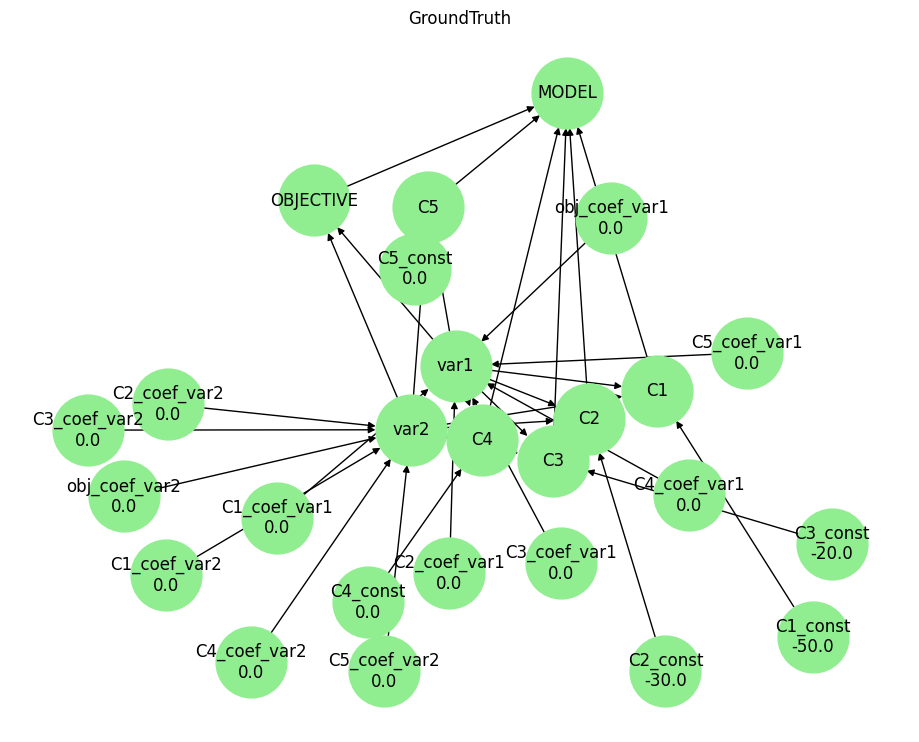

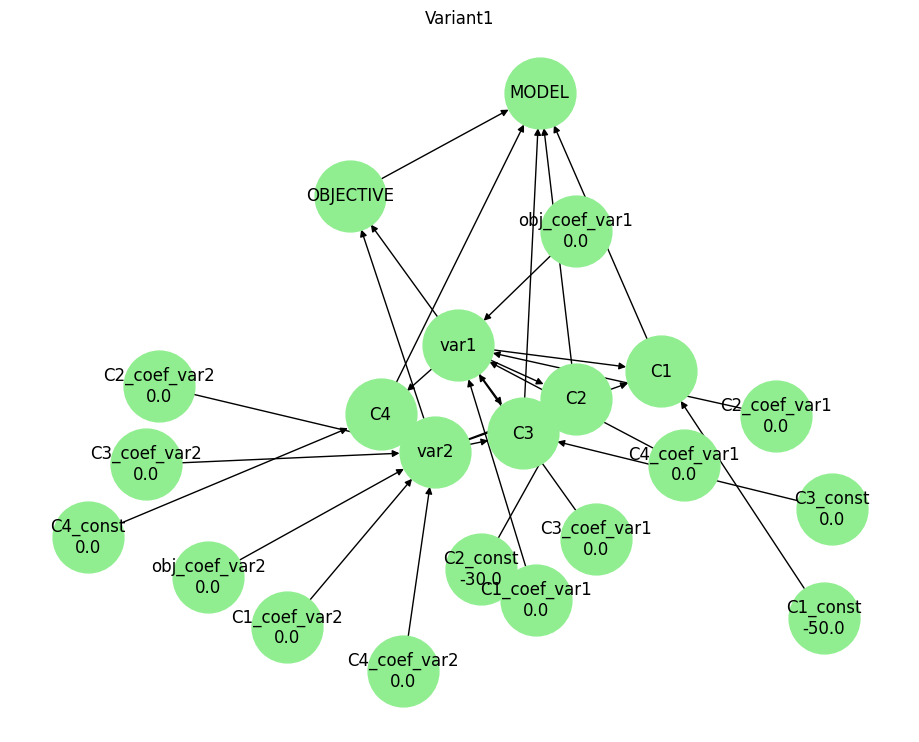

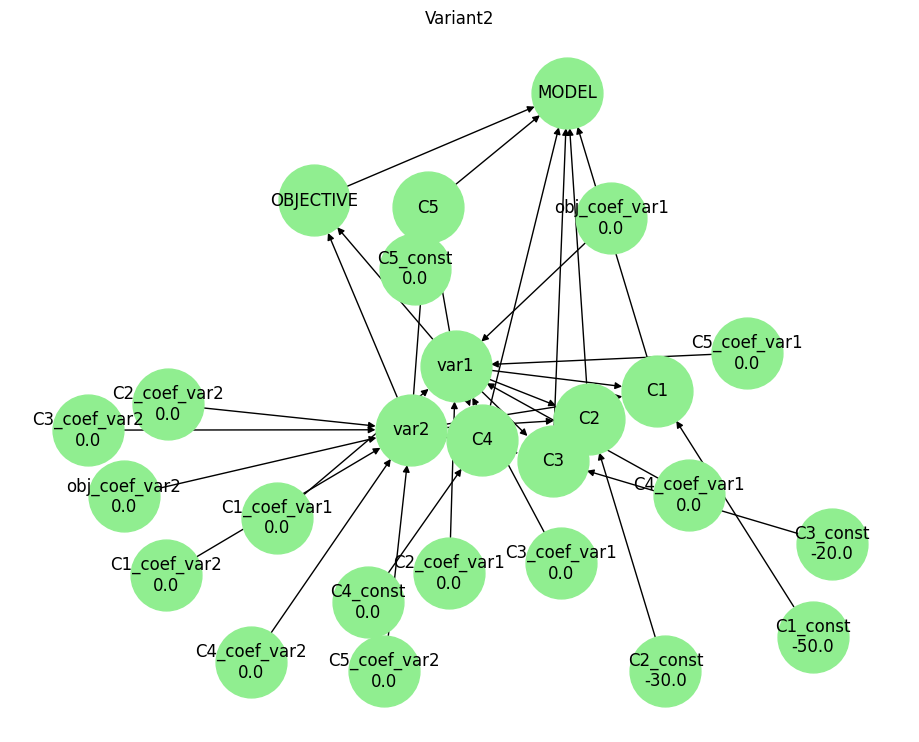

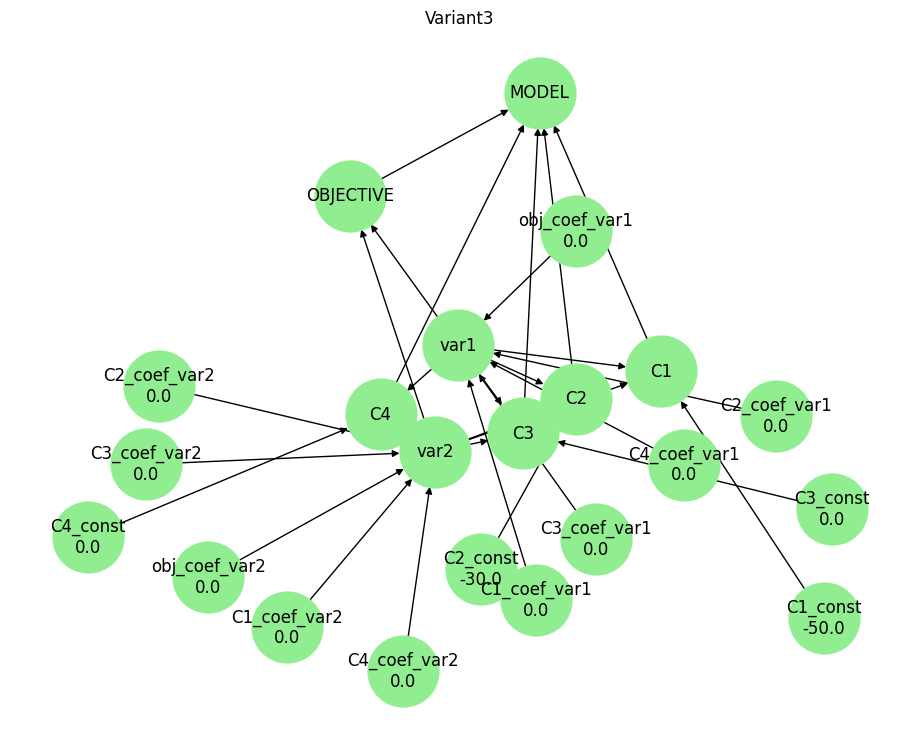

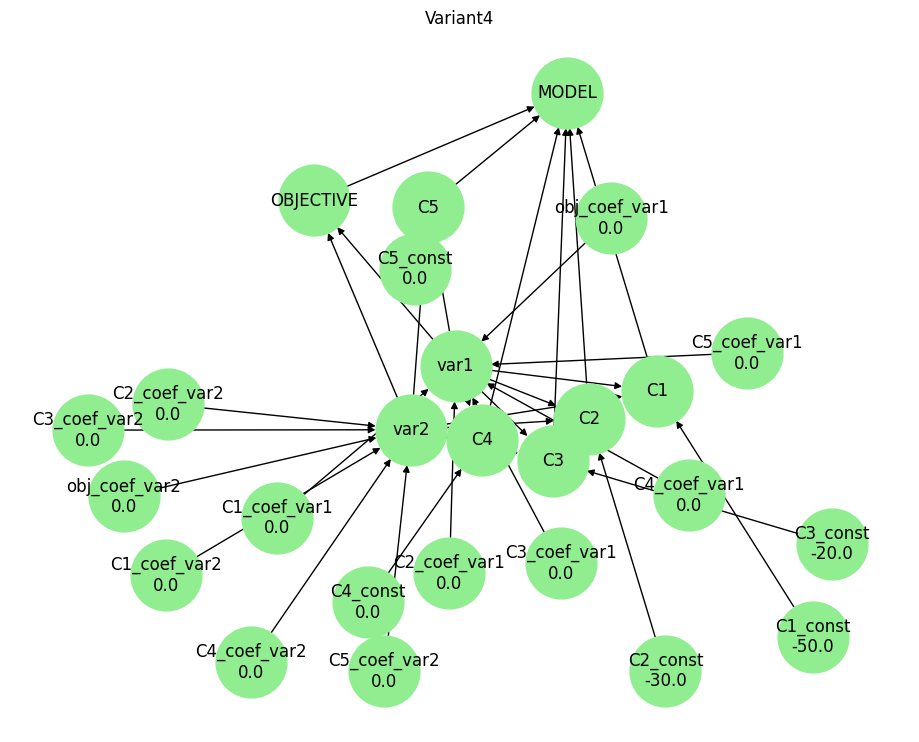

In [36]:
def draw_graph(G,title):

    pos=nx.spring_layout(G, seed=42)
    labels= {}

    for node in G.nodes(data=True):
        if "value" in node[1]:
            labels[node[0]] = f"{node[0]}\n{node[1]['value']}"
        else:
            labels[node[0]] = node[0]

    plt.figure(figsize=(9,7))
    
    nx.draw(G, pos,
            with_labels=False,
            node_size=2600,
            node_color="lightgreen")
    nx.draw_networkx_labels(G,pos,labels)

    plt.title(title)
    plt.show()

for name, G in graphs.items():
    draw_graph(G,name)